## Данные: MNIST

60k/10k изображений 28×28. Через `Subset` первые 10000 отданы под валидацию, остальные 50000 — на обучение.

In [1]:
import torch
import torchvision
from torchvision import transforms

image_path = './'

transform = transforms.Compose([
    transforms.ToTensor()
])

mnist_dataset = torchvision.datasets.MNIST(
    root=image_path, train=True,
    transform=transform, download=True
)

from torch.utils.data import Subset

mnist_valid_dataset = Subset(mnist_dataset,
    torch.arange(10000))

mnist_train_dataset = Subset(mnist_dataset,
    torch.arange(10000, len(mnist_dataset))
)

mnist_test_dataset = torchvision.datasets.MNIST(
    root=image_path, train=False,
    transform=transform, download=False
)

In [2]:
from torch.utils.data import DataLoader

batch_size = 64
torch.manual_seed(1)

train_dl = DataLoader(mnist_train_dataset,
    batch_size,
    shuffle=True)

valid_dl = DataLoader(mnist_valid_dataset,
    batch_size,
    shuffle=False)

## Архитектура: свёрточная часть

Conv2d(1→32, k=5, padding=2) → ReLU → MaxPool(2) → Conv2d(32→64, k=5, padding=2) → ReLU → MaxPool(2). Свёртки извлекают признаки, пулинг уменьшает разрешение: 28 → 14 → 7.

In [5]:
from torch import nn

model = nn.Sequential()
model.add_module(
    'conv1',
    nn.Conv2d(
        in_channels=1, out_channels=32,
        kernel_size=5, padding=2
    )
)
model.add_module('relu1', nn.ReLU())
model.add_module('pool1', nn.MaxPool2d(kernel_size=2))
model.add_module(
    'conv2',
    nn.Conv2d(
        in_channels=32, out_channels=64,
        kernel_size=5, padding=2
    )
)
model.add_module('relu2', nn.ReLU())
model.add_module('pool2', nn.MaxPool2d(kernel_size=2))

In [6]:
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 64, 7, 7])

После свёрток тензор имеет форму (batch, 64, 7, 7); `Flatten` превращает его в вектор 64·7·7 = 3136 для полносвязных слоёв.

In [8]:
model.add_module('flatten', nn.Flatten())
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 3136])

## Полносвязная часть

fc1 (3136→1024) → ReLU → Dropout(0.5) → fc2 (1024→10). Dropout — регуляризация: на обучении случайно обнуляет половину нейронов.

In [10]:
model.add_module('fc1', nn.Linear(3136, 1024))
model.add_module('relu3', nn.ReLU())
model.add_module('dropout', nn.Dropout(p=0.5))
model.add_module('fc2', nn.Linear(1024, 10))

## Loss и оптимизатор

`CrossEntropyLoss` (классификация на 10 цифр) + Adam (lr=0.001).

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  

## Цикл обучения

Стандартный цикл плюс валидация: в конце эпохи `model.eval()` и подсчёт loss/accuracy на val без `backward` (в `torch.no_grad()`). Режимы `train()`/`eval()` важны из-за Dropout.

In [13]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_list_train = [0] * num_epochs
    accuracy_list_train = [0] * num_epochs
    loss_list_valid = [0] * num_epochs
    accuracy_list_valid = [0] * num_epochs
    
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            loss_list_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            accuracy_list_train[epoch] += is_correct.sum()
        
        loss_list_train[epoch] /= len(train_dl.dataset)
        accuracy_list_train[epoch] /= len(train_dl.dataset)
        
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_list_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
                accuracy_list_valid[epoch] += is_correct.sum()
            
            loss_list_valid[epoch] /= len(valid_dl.dataset)
            accuracy_list_valid[epoch] /= len(valid_dl.dataset)
        
        print(f'Точность эпохи {epoch+1} : train_accuracy: {accuracy_list_train[epoch]:.4f} val_accuracy: {accuracy_list_valid[epoch]:.4f}')
    
    return loss_list_train, loss_list_valid, accuracy_list_train, accuracy_list_valid

## Обучение

10 эпох: val_accuracy растёт до ~0.99.

In [14]:
torch.manual_seed(1)
num_epochs = 10
hist = train(model, num_epochs, train_dl, valid_dl) 


Точность эпохи 1 : train_accuracy: 0.9491 val_accuracy: 0.9785
Точность эпохи 2 : train_accuracy: 0.9845 val_accuracy: 0.9857
Точность эпохи 3 : train_accuracy: 0.9887 val_accuracy: 0.9889
Точность эпохи 4 : train_accuracy: 0.9917 val_accuracy: 0.9902
Точность эпохи 5 : train_accuracy: 0.9930 val_accuracy: 0.9904
Точность эпохи 6 : train_accuracy: 0.9946 val_accuracy: 0.9900
Точность эпохи 7 : train_accuracy: 0.9953 val_accuracy: 0.9917
Точность эпохи 8 : train_accuracy: 0.9959 val_accuracy: 0.9900
Точность эпохи 9 : train_accuracy: 0.9957 val_accuracy: 0.9910
Точность эпохи 10 : train_accuracy: 0.9963 val_accuracy: 0.9908


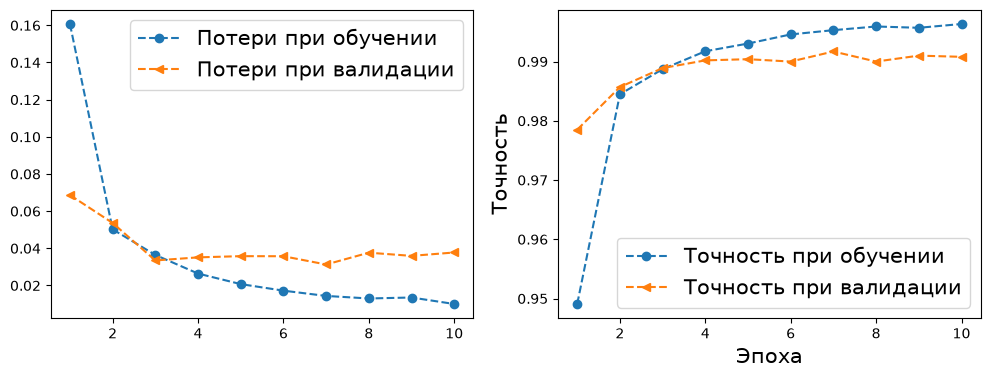

In [15]:
import matplotlib.pyplot as plt
import numpy as np

x_arr = np.arange(len(hist[0])) + 1

fig = plt.figure(figsize=(12, 4))

ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], '--o', label='Потери при обучении')
ax.plot(x_arr, hist[1], '--<', label='Потери при валидации')
ax.legend(fontsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], '--o', label='Точность при обучении')
ax.plot(x_arr, hist[3], '--<', label='Точность при валидации')
ax.legend(fontsize=15)
ax.set_xlabel('Эпоха', size=15)
ax.set_ylabel('Точность', size=15)

plt.show()

## Результаты

In [16]:
pred = model(mnist_test_dataset.data.unsqueeze(1) / 255.)
is_correct = (
    torch.argmax(pred, dim=1) == mnist_test_dataset.targets
).float()
print(f'Точность при тестировании: {is_correct.mean():.4f}')

Точность при тестировании: 0.9916
